# 약물 수요 예측 프로젝트 - Step 4: 평가
**목표**: 모델 예측 결과를 구별·약물별로 심층 분석하고 실무적 인사이트 도출  
**최우수 모델**: XGBoost (전체 MAPE 7.45% / A10A 12.31% / A10B 2.59%)

## 0. 환경 설정

In [21]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

OUT_DATA = 'output/data'
OUT_FIG  = 'output/figures'
os.makedirs(OUT_FIG, exist_ok=True)

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드

In [22]:
df_pred = pd.read_csv(f'{OUT_DATA}/test_predictions.csv', encoding='utf-8-sig')
df_pred['기간_dt'] = pd.to_datetime(df_pred['기간_dt'])

df_perf = pd.read_csv(f'{OUT_DATA}/model_performance.csv', encoding='utf-8-sig')
df_perf = df_perf.set_index('모델')

print(f'예측 결과 shape: {df_pred.shape}')
print(f'테스트 기간: {df_pred["기간_dt"].min().strftime("%Y-%m")} ~ {df_pred["기간_dt"].max().strftime("%Y-%m")}')
print()
print('전체 모델 성능:')
display(df_perf.style.format({'MAE': '{:,.1f}', 'RMSE': '{:,.1f}', 'MAPE': '{:.2f}%'})
        .highlight_min(color='none'))

예측 결과 shape: (300, 44)
테스트 기간: 2025-05 ~ 2025-10

전체 모델 성능:


,MAE,RMSE,MAPE
모델,,,
Linear Regression,"107,020.9","159,185.6",194.39%
XGBoost,"96,656.9","175,124.8",23.43%
LightGBM,"100,252.9","176,078.9",37.47%


## 2. 약물별 성능 비교 (A10A vs A10B)

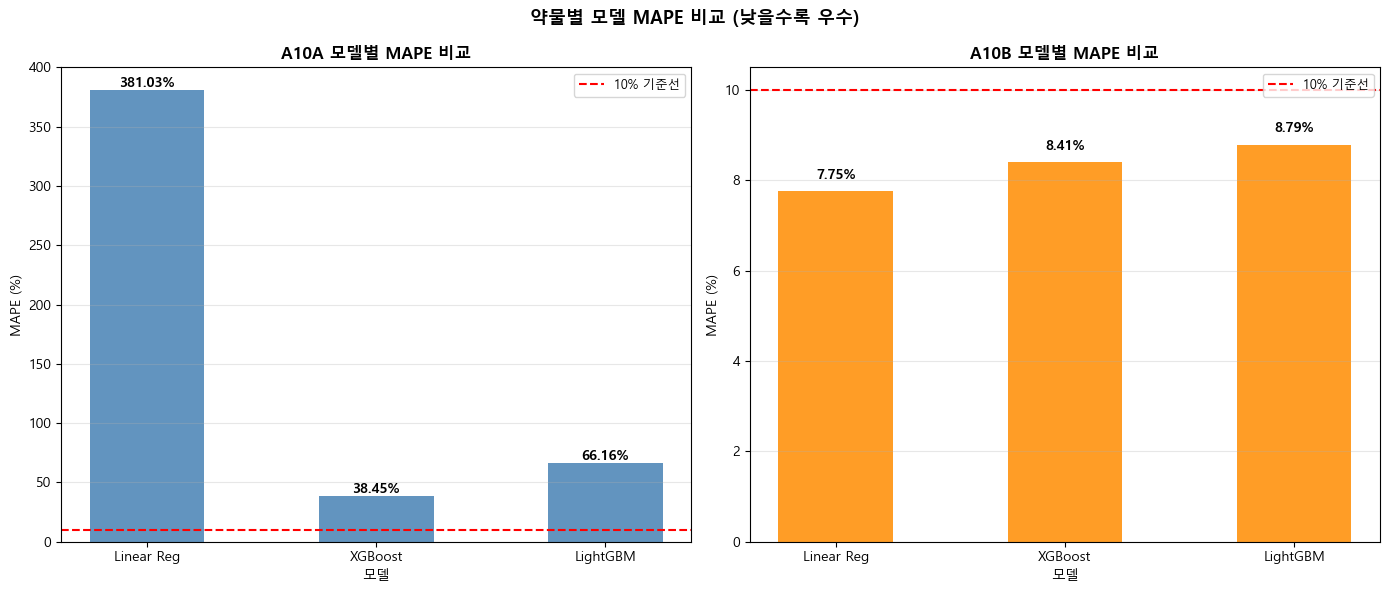

저장: output/figures/13_drug_mape_comparison.png



,약물,모델,MAE,RMSE,MAPE
0,A10A,Linear Reg,"33,926.0","39,829.6",381.03%
1,A10A,XGBoost,"2,870.8","3,771.3",38.45%
2,A10A,LightGBM,"6,269.4","8,904.3",66.16%
3,A10B,Linear Reg,"180,115.8","221,571.0",7.75%
4,A10B,XGBoost,"190,442.9","247,635.2",8.41%
5,A10B,LightGBM,"194,236.3","248,853.9",8.79%


In [23]:
# 약물별(A10A, A10B) 모델별 성능 지표 계산
drug_rows = []
for drug in ['A10A', 'A10B']:
    sub = df_pred[df_pred['약물구분'] == drug]
    for col, name in [('pred_lr','Linear Reg'), ('pred_xgb','XGBoost'), ('pred_lgb','LightGBM')]:
        drug_rows.append({
            '약물': drug, '모델': name,
            'MAE':  mae(sub['수량'].values, sub[col].values),
            'RMSE': rmse(sub['수량'].values, sub[col].values),
            'MAPE': mape(sub['수량'].values, sub[col].values),
        })

df_drug_perf = pd.DataFrame(drug_rows)

# 시각화 - 약물별 모델 MAPE 비교 막대 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, drug, color in zip(axes, ['A10A', 'A10B'], ['steelblue', 'darkorange']):
    data = df_drug_perf[df_drug_perf['약물'] == drug]
    bars = ax.bar(data['모델'], data['MAPE'], color=color, alpha=0.85, width=0.5)
    ax.axhline(10, color='red', linestyle='--', linewidth=1.5, label='10% 기준선')
    ax.set_title(f'{drug} 모델별 MAPE 비교', fontsize=12, fontweight='bold')
    ax.set_ylabel('MAPE (%)')
    ax.set_xlabel('모델')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, data['MAPE']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('약물별 모델 MAPE 비교 (낮을수록 우수)', fontsize=13, fontweight='bold')
plt.tight_layout()
path = f'{OUT_FIG}/13_drug_mape_comparison.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')
print()
display(df_drug_perf.style.format({'MAE': '{:,.1f}', 'RMSE': '{:,.1f}', 'MAPE': '{:.2f}%'})
        .highlight_min(subset=['MAPE'], color='none')
        .set_caption('약물별 모델 성능 비교'))

## 3. 구별 예측 성능 분석 (XGBoost 기준)

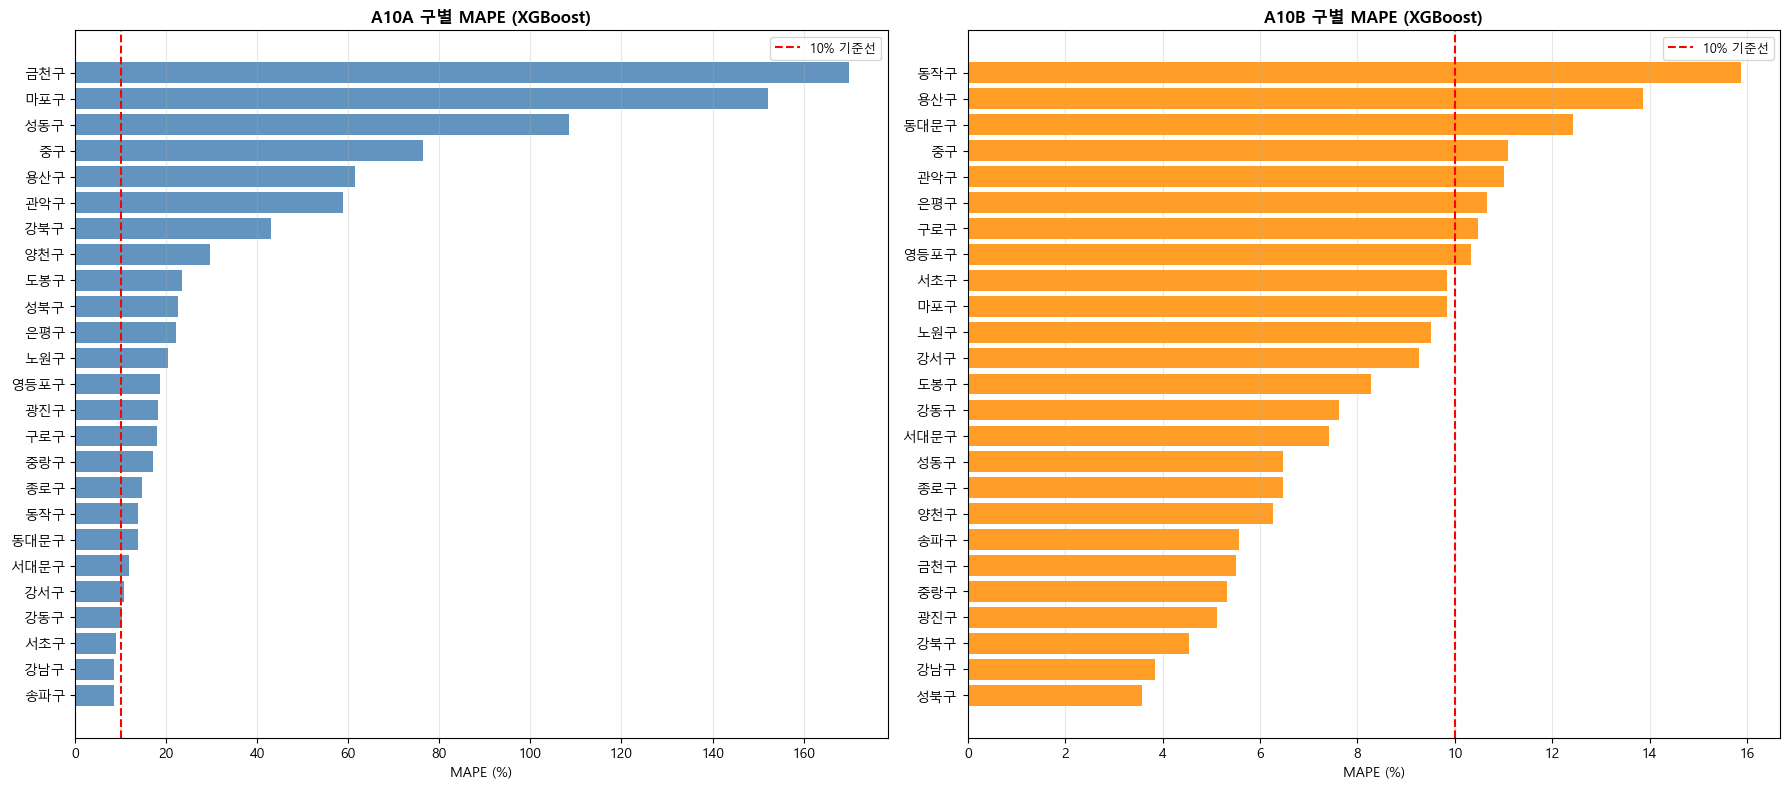

저장: output/figures/14_gu_mape_xgb.png

[A10A] 예측 우수 구 (MAPE 낮은 순):


,구,MAPE_xgb,MAE_xgb,평균_실제
17,송파구,8.62%,"2,753","32,430"
0,강남구,8.63%,"3,216","37,826"
14,서초구,8.88%,"1,362","15,572"
1,강동구,10.21%,"2,233","21,912"
3,강서구,10.77%,"1,557","14,372"


[A10A] 예측 어려운 구 (MAPE 높은 순):


,구,MAPE_xgb,MAE_xgb,평균_실제
20,용산구,61.42%,"3,026","4,954"
23,중구,76.33%,"2,377","3,174"
15,성동구,108.45%,"6,073","5,708"
12,마포구,152.21%,"5,075","3,324"
7,금천구,169.95%,"3,913","2,292"


[A10B] 예측 우수 구 (MAPE 낮은 순):


,구,MAPE_xgb,MAE_xgb,평균_실제
41,성북구,3.57%,"81,050","2,260,876"
25,강남구,3.85%,"157,288","3,889,250"
27,강북구,4.55%,"66,142","1,445,222"
30,광진구,5.11%,"102,942","2,006,339"
49,중랑구,5.33%,"103,987","1,969,136"


[A10B] 예측 어려운 구 (MAPE 높은 순):


,구,MAPE_xgb,MAE_xgb,평균_실제
29,관악구,11.02%,"178,308","1,658,755"
48,중구,11.10%,"108,533","998,220"
35,동대문구,12.44%,"323,899","2,594,192"
45,용산구,13.87%,"127,725","907,372"
36,동작구,15.88%,"394,014","2,434,645"


In [24]:
gu_rows = []
for drug in ['A10A', 'A10B']:
    sub = df_pred[df_pred['약물구분'] == drug]
    for gu, grp in sub.groupby('시군구명칭'):
        gu_rows.append({
            '약물': drug,
            '구': gu,
            'MAPE_xgb': mape(grp['수량'].values, grp['pred_xgb'].values),
            'MAE_xgb':  mae(grp['수량'].values, grp['pred_xgb'].values),
            '평균_실제': grp['수량'].mean(),
        })

df_gu = pd.DataFrame(gu_rows)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, drug, color in zip(axes, ['A10A', 'A10B'], ['steelblue', 'darkorange']):
    data = df_gu[df_gu['약물'] == drug].sort_values('MAPE_xgb', ascending=False)
    bars = ax.barh(data['구'][::-1], data['MAPE_xgb'][::-1], color=color, alpha=0.85)
    ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='10% 기준선')
    ax.set_title(f'{drug} 구별 MAPE (XGBoost)', fontsize=12, fontweight='bold')
    ax.set_xlabel('MAPE (%)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
path = f'{OUT_FIG}/14_gu_mape_xgb.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')
print()

# 성능 상위/하위 구 출력
for drug in ['A10A', 'A10B']:
    data = df_gu[df_gu['약물'] == drug].sort_values('MAPE_xgb')
    print(f'[{drug}] 예측 우수 구 (MAPE 낮은 순):')
    display(data[['구','MAPE_xgb','MAE_xgb','평균_실제']].head(5)
            .style.format({'MAPE_xgb': '{:.2f}%', 'MAE_xgb': '{:,.0f}', '평균_실제': '{:,.0f}'}))
    print(f'[{drug}] 예측 어려운 구 (MAPE 높은 순):')
    display(data[['구','MAPE_xgb','MAE_xgb','평균_실제']].tail(5)
            .style.format({'MAPE_xgb': '{:.2f}%', 'MAE_xgb': '{:,.0f}', '평균_실제': '{:,.0f}'}))

## 4. 월별 예측 오차 추이

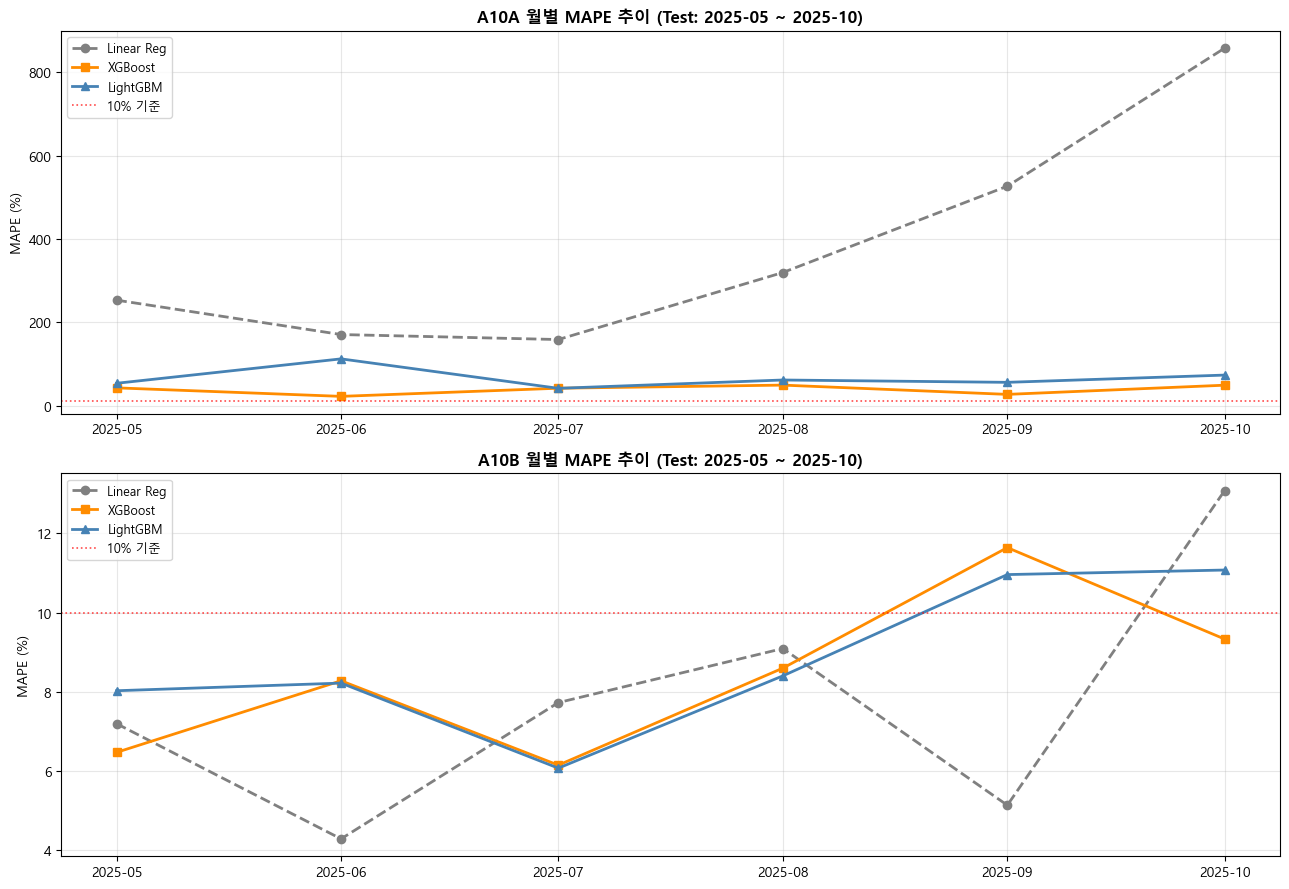

저장: output/figures/15_monthly_mape_trend.png


In [25]:
month_rows = []
for drug in ['A10A', 'A10B']:
    sub = df_pred[df_pred['약물구분'] == drug]
    for dt, grp in sub.groupby('기간_dt'):
        month_rows.append({
            '약물': drug, '기간': dt,
            'MAPE_lr':  mape(grp['수량'].values, grp['pred_lr'].values),
            'MAPE_xgb': mape(grp['수량'].values, grp['pred_xgb'].values),
            'MAPE_lgb': mape(grp['수량'].values, grp['pred_lgb'].values),
        })
df_month = pd.DataFrame(month_rows)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
line_styles = [
    ('MAPE_lr',  'Linear Reg', 'gray',       '--', 'o'),
    ('MAPE_xgb', 'XGBoost',    'darkorange',  '-', 's'),
    ('MAPE_lgb', 'LightGBM',   'steelblue',   '-', '^'),
]
for ax, drug in zip(axes, ['A10A', 'A10B']):
    data = df_month[df_month['약물'] == drug].sort_values('기간')
    for col, label, color, ls, marker in line_styles:
        ax.plot(data['기간'], data[col], label=label, color=color,
                linestyle=ls, marker=marker, markersize=6, linewidth=2)
    ax.axhline(10, color='red', linestyle=':', linewidth=1.2, alpha=0.7, label='10% 기준')
    ax.set_title(f'{drug} 월별 MAPE 추이 (Test: 2025-05 ~ 2025-10)', fontsize=12, fontweight='bold')
    ax.set_ylabel('MAPE (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y-%m'))

plt.tight_layout()
path = f'{OUT_FIG}/15_monthly_mape_trend.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 5. 전체 합계 기준 예측 vs 실제 시계열

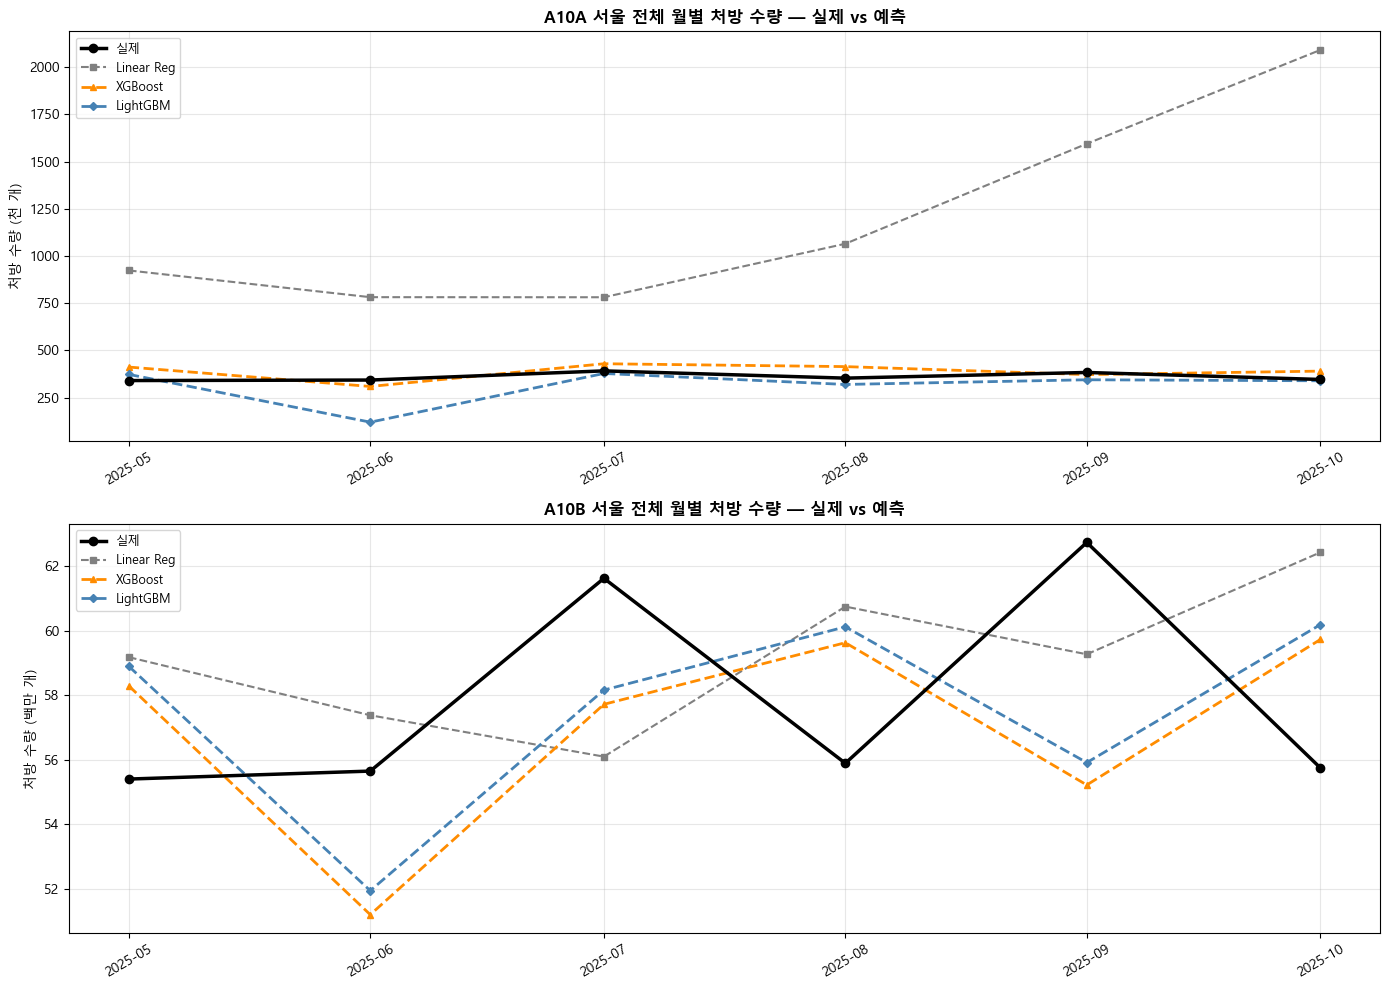

저장: output/figures/16_total_pred_vs_actual.png


In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, drug, scale, unit in zip(
    axes,
    ['A10A', 'A10B'],
    [1e3,    1e6],
    ['천 개', '백만 개']
):
    sub = df_pred[df_pred['약물구분'] == drug].groupby('기간_dt').agg(
        실제=('수량','sum'),
        pred_lr=('pred_lr','sum'),
        pred_xgb=('pred_xgb','sum'),
        pred_lgb=('pred_lgb','sum'),
    ).reset_index()

    ax.plot(sub['기간_dt'], sub['실제']/scale,    color='black',      linewidth=2.5, label='실제', marker='o', markersize=6, zorder=5)
    ax.plot(sub['기간_dt'], sub['pred_lr']/scale,  color='gray',       linewidth=1.5, label='Linear Reg', linestyle='--', marker='s', markersize=4)
    ax.plot(sub['기간_dt'], sub['pred_xgb']/scale, color='darkorange', linewidth=2,   label='XGBoost', linestyle='--', marker='^', markersize=5)
    ax.plot(sub['기간_dt'], sub['pred_lgb']/scale, color='steelblue',  linewidth=2,   label='LightGBM', linestyle='--', marker='D', markersize=4)

    ax.set_title(f'{drug} 서울 전체 월별 처방 수량 — 실제 vs 예측', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'처방 수량 ({unit})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
path = f'{OUT_FIG}/16_total_pred_vs_actual.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 6. 인구 특성과 예측 오차의 관계

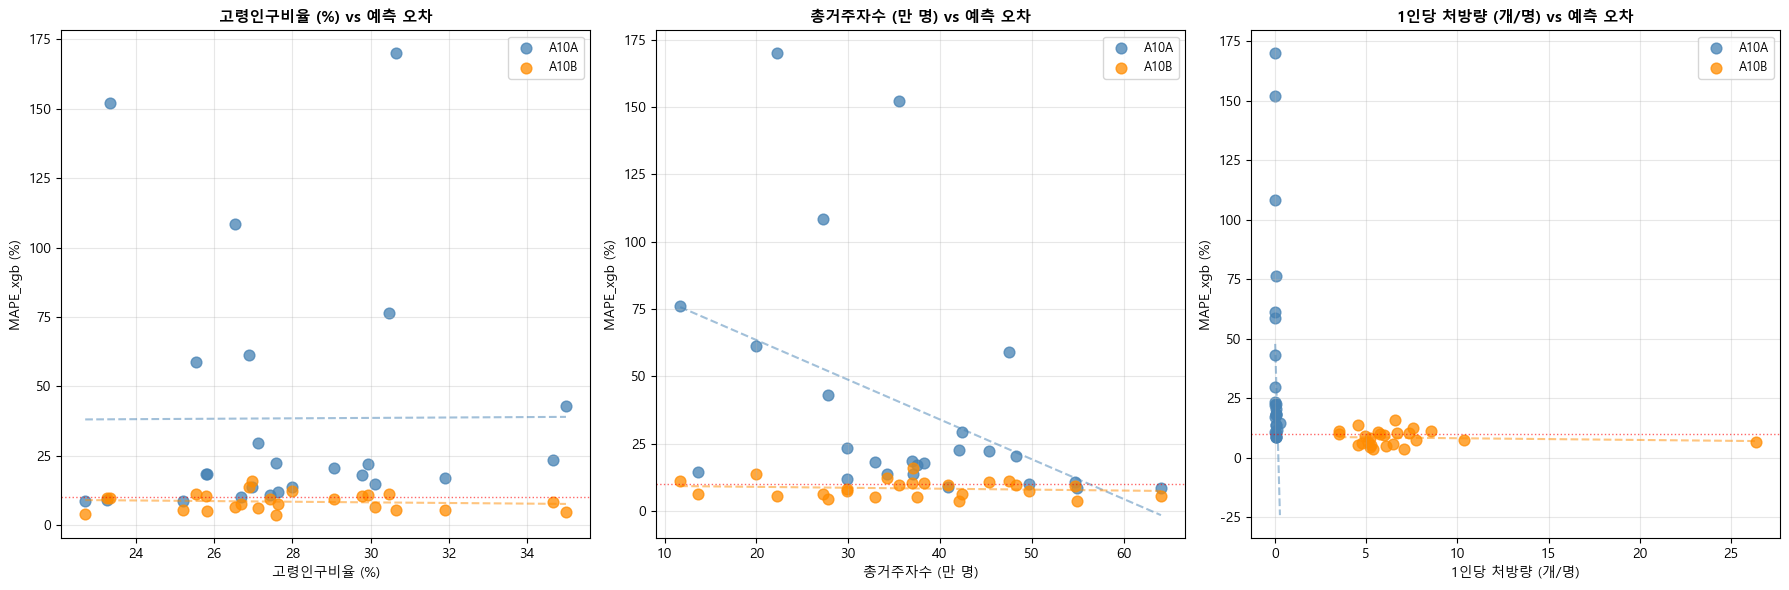

저장: output/figures/17_population_vs_error.png


In [27]:
df_gu_pop = df_pred.groupby(['약물구분','시군구명칭']).agg(
    MAPE_xgb=('수량', lambda x: mape(x.values, df_pred.loc[x.index,'pred_xgb'].values)),
    고령인구비율=('고령인구비율','mean'),
    총거주자수=('총거주자수','mean'),
    처방량_per_capita=('처방량_per_capita','mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
scatter_vars = [
    ('고령인구비율', '고령인구비율 (%)', lambda x: x*100),
    ('총거주자수',   '총거주자수 (만 명)', lambda x: x/1e4),
    ('처방량_per_capita', '1인당 처방량 (개/명)', lambda x: x),
]
colors_drug = {'A10A': 'steelblue', 'A10B': 'darkorange'}

for ax, (col, xlabel, transform) in zip(axes, scatter_vars):
    for drug, grp in df_gu_pop.groupby('약물구분'):
        ax.scatter(transform(grp[col]), grp['MAPE_xgb'],
                   label=drug, color=colors_drug[drug], alpha=0.75, s=60)
        # 추세선
        x_val = transform(grp[col]).values
        y_val = grp['MAPE_xgb'].values
        if len(x_val) > 2:
            z = np.polyfit(x_val, y_val, 1)
            p = np.poly1d(z)
            x_line = np.linspace(x_val.min(), x_val.max(), 50)
            ax.plot(x_line, p(x_line), '--', color=colors_drug[drug], alpha=0.5, linewidth=1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('MAPE_xgb (%)')
    ax.set_title(f'{xlabel} vs 예측 오차', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(10, color='red', linestyle=':', linewidth=1, alpha=0.6)

plt.tight_layout()
path = f'{OUT_FIG}/17_population_vs_error.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 7. 최종 성능 요약

## 7-1. R² (결정계수) 분석

=== R² 결과 ===
  해석 기준: > 0.95 매우 우수 / > 0.9 우수 / > 0.7 양호 / 음수 = 평균보다 나쁨



R²,A10A,A10B,전체
모델,,,
LightGBM,0.2489,0.9269,0.9822
Linear Reg,-14.0284,0.9420,0.9855
XGBoost,0.8653,0.9276,0.9824


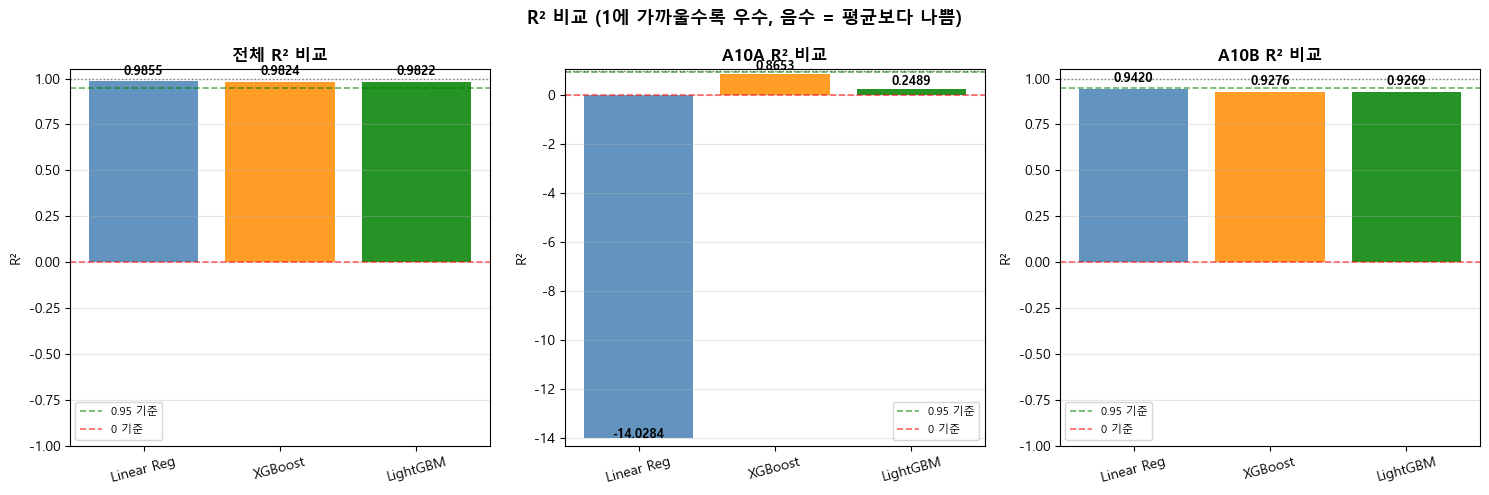

저장: output/figures/18_r2_comparison.png


In [28]:
from sklearn.metrics import r2_score

# 약물별 / 모델별 R² 계산
r2_rows = []
for scope in ['전체', 'A10A', 'A10B']:
    sub = df_pred if scope == '전체' else df_pred[df_pred['약물구분'] == scope]
    for col, name in [('pred_lr','Linear Reg'), ('pred_xgb','XGBoost'), ('pred_lgb','LightGBM')]:
        r2_rows.append({
            '약물': scope, '모델': name,
            'R²': r2_score(sub['수량'], sub[col])
        })

df_r2 = pd.DataFrame(r2_rows)
pivot_r2 = df_r2.pivot_table(index='모델', columns='약물', values='R²')
pivot_r2.columns.name = 'R²'

print('=== R² 결과 ===')
print('  해석 기준: > 0.95 매우 우수 / > 0.9 우수 / > 0.7 양호 / 음수 = 평균보다 나쁨')
print()
display(pivot_r2.style.format('{:.4f}')
        .highlight_max(axis=0, color='none')
        .highlight_min(axis=0, color='none')
        .set_caption('모델별 약물별 R² (높을수록 우수)'))

# R² 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
drugs = ['전체', 'A10A', 'A10B']
colors = ['steelblue', 'darkorange', 'green']

for ax, drug in zip(axes, drugs):
    data = df_r2[df_r2['약물'] == drug]
    bars = ax.bar(data['모델'], data['R²'], color=colors, alpha=0.85)
    ax.set_title(f'{drug} R² 비교', fontsize=12, fontweight='bold')
    ax.set_ylabel('R²')
    ax.set_ylim(min(-1, data['R²'].min() - 0.3), 1.05)
    ax.axhline(1.0, color='gray',  linestyle=':', linewidth=1)
    ax.axhline(0.95, color='green', linestyle='--', linewidth=1.2, alpha=0.6, label='0.95 기준')
    ax.axhline(0.0, color='red',   linestyle='--', linewidth=1.2, alpha=0.6, label='0 기준')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, data['R²']):
        ypos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.1
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('R² 비교 (1에 가까울수록 우수, 음수 = 평균보다 나쁨)', fontsize=13, fontweight='bold')
plt.tight_layout()
path = f'{OUT_FIG}/18_r2_comparison.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')


In [29]:
print('=' * 60)
print('최종 모델 성능 요약')
print('=' * 60)

summary = []
for drug in ['A10A', 'A10B', '전체']:
    sub = df_pred if drug == '전체' else df_pred[df_pred['약물구분'] == drug]
    for col, name in [('pred_lr','Linear Reg'), ('pred_xgb','XGBoost'), ('pred_lgb','LightGBM')]:
        summary.append({
            '약물': drug, '모델': name,
            'MAE':  mae(sub['수량'].values, sub[col].values),
            'RMSE': rmse(sub['수량'].values, sub[col].values),
            'MAPE': mape(sub['수량'].values, sub[col].values),
        })

df_summary = pd.DataFrame(summary)
pivot = df_summary.pivot_table(index='모델', columns='약물', values='MAPE').round(2)
pivot.columns.name = 'MAPE (%)'
display(pivot.style.format('{:.2f}%')
        .highlight_min(axis=0, color='none')
        .set_caption('모델별 약물별 MAPE (낮을수록 우수)'))

print()
best = df_summary[df_summary['약물']=='전체'].sort_values('MAPE').iloc[0]
print(f'최우수 모델  : {best["모델"]}')
print(f'전체 MAPE   : {best["MAPE"]:.2f}%')
print(f'A10A MAPE  : {df_summary[(df_summary["약물"]=="A10A")&(df_summary["모델"]==best["모델"])]["MAPE"].values[0]:.2f}%')
print(f'A10B MAPE  : {df_summary[(df_summary["약물"]=="A10B")&(df_summary["모델"]==best["모델"])]["MAPE"].values[0]:.2f}%')

최종 모델 성능 요약


MAPE (%),A10A,A10B,전체
모델,,,
LightGBM,66.16%,8.79%,37.47%
Linear Reg,381.03%,7.75%,194.39%
XGBoost,38.45%,8.41%,23.43%



최우수 모델  : XGBoost
전체 MAPE   : 23.43%
A10A MAPE  : 38.45%
A10B MAPE  : 8.41%


## 8. 한계 및 개선 방향

### 현재 모델의 한계

| 항목 | 내용 |
|---|---|
| 데이터 범위 | 서울시 25개 구만 분석 (전국 확장 필요) |
| 인구 데이터 | 2025-10 단일 스냅샷 → 전 기간 동일 적용 (실제 월별 인구 변화 미반영) |
| 테스트 기간 | 6개월로 짧음 → 계절성 패턴 검증 불충분 |
| A10A 성능 | MAPE 12.31% → 처방 규모가 작은 구에서 오차 큼 |
| LightGBM | XGBoost 대비 성능 낮음 → 하이퍼파라미터 최적화 필요 |

### 개선 방향

1. **데이터 확장**: 전국 시군구 데이터 확보 시 일반화 성능 대폭 향상 예상
2. **인구 데이터 시계열화**: 연도별 인구 데이터 수집으로 feature 품질 향상
3. **A10A 개별 모델**: 소규모 구와 대규모 구를 분리하여 별도 모델 학습 검토
4. **하이퍼파라미터 튜닝**: Optuna 등으로 XGBoost/LightGBM 최적화
5. **외부 변수 추가**: 기온(겨울 인슐린 사용 증가), 의료기관 수 등 추가 검토


## 9. 최종 평가 결과 저장

In [30]:
# 구별 성능 저장
df_gu.to_csv(f'{OUT_DATA}/gu_performance.csv', index=False, encoding='utf-8-sig')

# 약물별 성능 저장
df_drug_perf.to_csv(f'{OUT_DATA}/drug_performance.csv', index=False, encoding='utf-8-sig')

# 전체 요약 저장
df_summary.to_csv(f'{OUT_DATA}/final_summary.csv', index=False, encoding='utf-8-sig')

print('저장 완료:')
print(f'  {OUT_DATA}/gu_performance.csv')
print(f'  {OUT_DATA}/drug_performance.csv')
print(f'  {OUT_DATA}/final_summary.csv')
print()
print('=' * 55)
print('프로젝트 완료')
print('=' * 55)
print()
print('[생성된 시각화 파일 전체]')
for f in sorted(os.listdir(OUT_FIG)):
    print(f'  output/figures/{f}')
import os


저장 완료:
  output/data/gu_performance.csv
  output/data/drug_performance.csv
  output/data/final_summary.csv

프로젝트 완료

[생성된 시각화 파일 전체]
  output/figures/01_monthly_trend.png
  output/figures/02_gu_distribution.png
  output/figures/02_gu_top_bottom.png
  output/figures/03_population_vs_demand.png
  output/figures/04_institution_type.png
  output/figures/05_disease_analysis.png
  output/figures/06_correlation_heatmap.png
  output/figures/07_boxplot_by_gu.png
  output/figures/08_per_capita_by_gu.png
  output/figures/09_model_comparison.png
  output/figures/10_feature_importance.png
  output/figures/11_pred_vs_actual.png
  output/figures/12_residual_plot.png
  output/figures/13_drug_mape_comparison.png
  output/figures/14_gu_mape_xgb.png
  output/figures/15_monthly_mape_trend.png
  output/figures/16_total_pred_vs_actual.png
  output/figures/17_population_vs_error.png
  output/figures/18_r2_comparison.png
